In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Period

In [3]:
iyear = 1981
fyear = 2015
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']
domain = 'HMA'
seasons = ['DJFM','AM','JJAS','ON']

# TP timeseries DATASETS & DOMAINS

In [4]:
tp_datasets = {}
stats_datasets = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for season in seasons:
        tp_datasets[model][season] = pd.read_csv(path + f'timeseries_tp_{season}_{domain}_1981-2015_{model}.csv')
        stats_datasets[model][season] = pd.read_csv(path + f'stats_tp_{season}_{domain}_1981-2015_{model}.csv')



In [ ]:
ref_model = 'ERA5'

for season in seasons:
    coherence = pd.DataFrame(index=models, columns=['coherence'], dtype=float)
    
    # référence
    ref_df = tp_datasets[ref_model][domain][['year', 'tp']]
    
    for model in models:
        df = tp_datasets[model][domain][['year', 'tp']]
    
        # merge sur les années communes
        merged = pd.merge(
            ref_df,
            df,
            on='year',
            suffixes=('_ref', '_model')
        ).dropna()
        
        # corrélation (Pearson)
        corr = merged['tp_ref'].corr(merged['tp_model'])
    
        coherence.loc[model, 'coherence'] = corr
    
    display(coherence.style.format("{:.2f}"))

'DJFM'

,trend,std error,mean,std,coherence
APHRO,0.81,0.06,15.16,3.62,0.60
GPCP,-0.56,0.05,16.99,3.19,0.93
CRU,-0.62,0.05,17.13,2.82,0.95
CHIRPS,0.02,0.04,16.23,2.06,0.75
HARv2,-1.10,0.08,28.86,4.50,0.96
ERA5,-1.66,0.07,27.25,4.13,1.00


'AM'

,trend,std error,mean,std,coherence
APHRO,2.39,0.08,38.47,5.42,0.37
GPCP,0.01,0.07,43.05,4.12,0.85
CRU,-0.43,0.07,42.41,4.37,0.80
CHIRPS,1.46,0.06,42.35,4.04,0.56
HARv2,-1.03,0.08,58.41,4.89,0.82
ERA5,-1.64,0.09,59.99,5.57,1.00


'JJAS'

,trend,std error,mean,std,coherence
APHRO,2.46,0.11,87.48,6.66,0.61
GPCP,0.50,0.09,104.55,5.47,0.93
CRU,0.47,0.09,97.86,5.21,0.80
CHIRPS,2.59,0.09,101.60,5.71,0.70
HARv2,0.94,0.14,104.56,8.12,0.72
ERA5,0.24,0.10,126.01,6.09,1.00


'ON'

,trend,std error,mean,std,coherence
APHRO,0.96,0.06,22.38,3.85,0.66
GPCP,-0.24,0.06,24.89,3.43,0.88
CRU,0.07,0.06,24.91,3.44,0.76
CHIRPS,0.71,0.05,24.18,2.88,0.63
HARv2,0.04,0.06,27.96,3.65,0.65
ERA5,-1.08,0.06,35.69,3.52,1.00


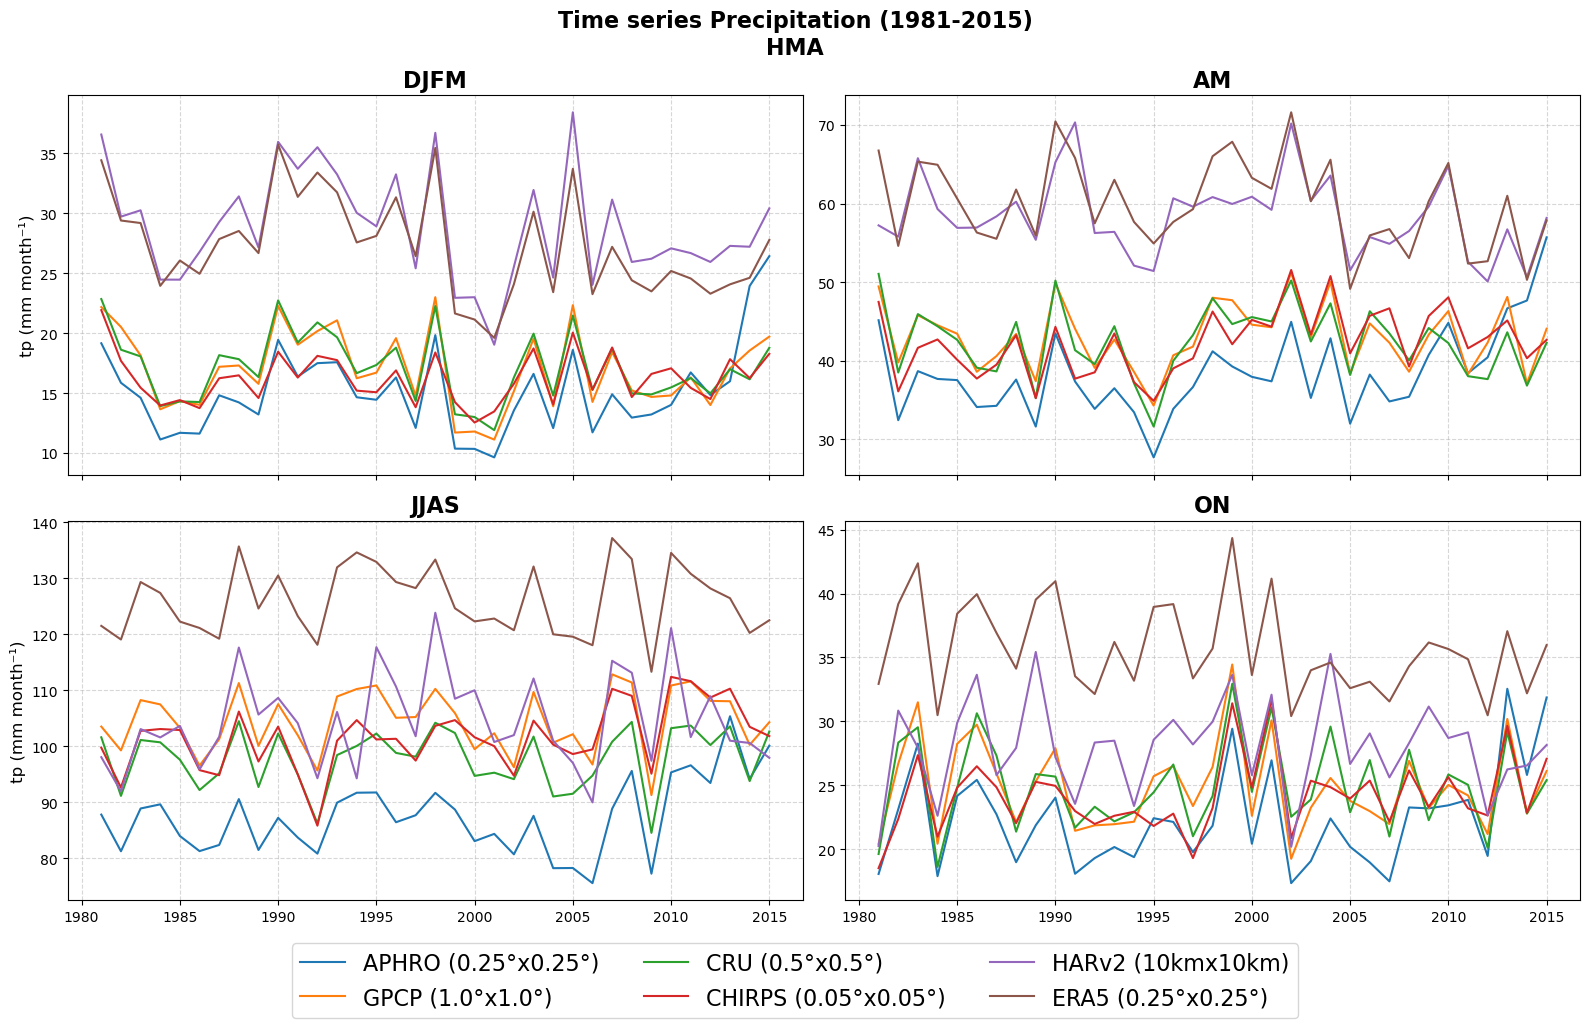

In [16]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

ref_model = 'ERA5'

#============== tableau des p-values ==========================

cols = ['trend', 'std error', 'mean', 'std', 'coherence']
table = pd.DataFrame(index=models, columns=cols)
pvals = pd.Series(index=models)

for season in seasons:
    coherence = pd.DataFrame(index=models, columns=['coherence'], dtype=float)
    
    # référence
    ref_df = tp_datasets[ref_model][season][['year', 'tp']]
    for model in models:
        df = stats_datasets[model][season]
    
        table.loc[model, 'trend'] = df.loc[df['stat']=='slope','value'].values[0] * 10
        table.loc[model, 'mean']  = df.loc[df['stat']=='mean','value'].values[0]
        table.loc[model, 'std']   = df.loc[df['stat']=='std','value'].values[0]
        table.loc[model, 'std error'] = df.loc[df['stat']=='std_err','value'].values[0]
    
        pvals.loc[model] = df.loc[df['stat']=='p_value','value'].values[0]

        df = tp_datasets[model][season][['year', 'tp']]
    
        # merge sur les années communes
        merged = pd.merge(
            ref_df,
            df,
            on='year',
            suffixes=('_ref', '_model')
        ).dropna()
        
        # corrélation (Pearson)
        corr = merged['tp_ref'].corr(merged['tp_model'])
        
        table.loc[model, 'coherence'] = corr

    def bold_sig(val, p):
        if p < 0.05:
            return 'font-weight: bold'
        return ''
    
    styled_table = table.style.apply(
        lambda x: [
            bold_sig(v, pvals.loc[x.name]) if col == 'trend' else ''
            for col, v in x.items()
        ],
        axis=1
    ).format("{:.2f}")

    display(season)
    display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

for i, season in enumerate(seasons):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][season]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=1.5)

    ax.set_title(season, fontsize=16, weight="bold")
    
    if i in [0, 2]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [2, 3]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Time series Precipitation ({iyear}-{fyear})\nHMA', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()